# High-dimensional Gaussian–LogGamma benchmark: Dynesty → Morph → MINS

This notebook follows the workflow of the existing MINS eggbox example:

1. Define the normalized Gaussian–LogGamma benchmark and its uniform prior.
2. Run **Dynesty** to estimate the evidence and generate posterior samples.
3. Fit a **MorphZ** approximation to the equal-weight Dynesty posterior.
4. Run **MINS** using the fitted Morph as its fixed importance distribution.
5. Compare evidence accuracy, computational cost, posterior marginals, and mode occupancy.

The benchmark is defined for an even number of dimensions. It contains four modes in
the first two coordinates and asymmetric heavy-tailed LogGamma marginals in half of the
remaining coordinates. With the likelihood normalization used here and a uniform prior
on $[-5,5]^D$, the reference evidence is $\log Z \simeq 0$. The notebook also computes
the tiny exact finite-boundary correction.

**Important:** MINS uses the Dynesty posterior to fit its fixed Morph proposal. If Dynesty
misses a mode or a heavy tail, the fitted Morph may also miss it, and MINS cannot
automatically reconstruct omitted proposal support. Repeated runs and larger live sets
are therefore essential for a scientific benchmark.

## Environment

Run this notebook from the MINS repository after installing its dependencies:

```bash
python -m pip install -e ".[morph,progress]"
python -m pip install dynesty scipy matplotlib corner pandas
```

The default configuration below is the full $D=30$ benchmark. Reduce `NDIM`,
`DYNESTY_NLIVE`, or `MINS_NLIVE` only for a quick smoke test.

In [8]:
from __future__ import annotations

import platform
import time

import corner
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from dynesty import NestedSampler
from dynesty import __version__ as dynesty_version
from dynesty import utils as dyfunc
from scipy.stats import loggamma, norm

from mins import (
    CallableModel,
    EnsembleRWalkSettings,
    MINSampler,
    MorphProposal,
)
from mins.diagnostics import summarize

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Dynesty:", dynesty_version)

Python: 3.10.16
NumPy: 1.26.4
SciPy: 1.13.1
Dynesty: 2.1.5


## 1. Benchmark and sampler configuration

In [9]:
# Reproducibility
SEED = 1234

# The benchmark requires an even NDIM >= 2.
# Use NDIM = 10 for a quicker test, and 30, 50, or 100 for scaling studies.
NDIM = 10

# Gaussian–LogGamma definition
PRIOR_MIN = -5.0
PRIOR_MAX = 5.0
LOGGAMMA_SHAPE = 1.0
MODE_LEFT = 1.0 / 3.0
MODE_RIGHT = 2.0 / 3.0
COMPONENT_SCALE = 1.0 / 30.0

# Dynesty configuration.
# "slice" is the safer default for this high-dimensional heavy-tailed problem.
# Change to "rwalk" for a direct random-walk comparison.
DYNESTY_NLIVE = 500
DYNESTY_DLOGZ = 0.1
DYNESTY_SAMPLE = "slice"
DYNESTY_BOUND = "multi"

# Morph fit
MORPH_TYPE = "2_group"
KDE_BW = "silverman"
MAX_MORPH_TRAINING_SAMPLES = 20_000

# MINS configuration
MINS_NLIVE = 500
MINS_DLOGZ = 0.01
MINS_N_WALKERS = 64
MINS_N_SWEEPS = 8
MINS_MAX_ITERATIONS = 200_000
MINS_MAX_PROPOSALS_PER_REPLACEMENT = 1_000_000
MINS_MAX_LIKELIHOOD_CALLS = 20_000_000

if NDIM < 2 or NDIM % 2:
    raise ValueError("NDIM must be an even integer greater than or equal to 2.")

PARAMETER_NAMES = tuple(f"x{i + 1}" for i in range(NDIM))

print(f"Running the Gaussian–LogGamma benchmark in D={NDIM}.")
print(f"Dynesty: nlive={DYNESTY_NLIVE}, sample={DYNESTY_SAMPLE!r}")
print(f"MINS: nlive={MINS_NLIVE}, proposal='en-rwalk'")

Running the Gaussian–LogGamma benchmark in D=10.
Dynesty: nlive=500, sample='slice'
MINS: nlive=500, proposal='en-rwalk'


## 2. Define the Gaussian–LogGamma likelihood and normalized prior

In [10]:
LOG_TWO = np.log(2.0)
PRIOR_WIDTH = PRIOR_MAX - PRIOR_MIN
LOG_PRIOR_DENSITY = -NDIM * np.log(PRIOR_WIDTH)


def log_equal_mixture(log_a: float, log_b: float) -> float:
    """Stable log of an equal-weight two-component mixture."""
    return float(np.logaddexp(log_a, log_b) - LOG_TWO)


def loglikelihood(theta: np.ndarray) -> float:
    """
    Gaussian–LogGamma benchmark log likelihood.

    Dimension 1:
        equal mixture of LogGamma distributions at 1/3 and 2/3.
    Dimension 2:
        equal mixture of Gaussian distributions at 1/3 and 2/3.
    Dimensions 3 ... D/2 + 1:
        LogGamma distribution at 2/3.
    Remaining dimensions:
        Gaussian distribution at 2/3.

    The D * log(10) normalization makes log Z approximately zero
    under the normalized U([-5, 5]^D) prior.
    """
    x = np.asarray(theta, dtype=float)
    if x.shape != (NDIM,):
        raise ValueError(f"Expected theta with shape ({NDIM},), got {x.shape}.")

    log_terms = np.empty(NDIM, dtype=float)

    log_terms[0] = log_equal_mixture(
        loggamma.logpdf(
            x[0],
            c=LOGGAMMA_SHAPE,
            loc=MODE_LEFT,
            scale=COMPONENT_SCALE,
        ),
        loggamma.logpdf(
            x[0],
            c=LOGGAMMA_SHAPE,
            loc=MODE_RIGHT,
            scale=COMPONENT_SCALE,
        ),
    )

    log_terms[1] = log_equal_mixture(
        norm.logpdf(x[1], loc=MODE_LEFT, scale=COMPONENT_SCALE),
        norm.logpdf(x[1], loc=MODE_RIGHT, scale=COMPONENT_SCALE),
    )

    split = NDIM // 2 + 1
    log_terms[2:split] = loggamma.logpdf(
        x[2:split],
        c=LOGGAMMA_SHAPE,
        loc=MODE_RIGHT,
        scale=COMPONENT_SCALE,
    )
    log_terms[split:] = norm.logpdf(
        x[split:],
        loc=MODE_RIGHT,
        scale=COMPONENT_SCALE,
    )

    return float(NDIM * np.log(10.0) + np.sum(log_terms))


def logprior(theta: np.ndarray) -> float:
    """Normalized uniform log prior on [-5, 5]^D."""
    x = np.asarray(theta, dtype=float)
    if x.shape != (NDIM,):
        raise ValueError(f"Expected theta with shape ({NDIM},), got {x.shape}.")
    if np.all((x >= PRIOR_MIN) & (x <= PRIOR_MAX)):
        return float(LOG_PRIOR_DENSITY)
    return -np.inf


def prior_transform(unit_cube: np.ndarray) -> np.ndarray:
    """Map Dynesty's unit cube to the physical prior."""
    u = np.asarray(unit_cube, dtype=float)
    return PRIOR_MIN + PRIOR_WIDTH * u


def exact_logz(ndim: int = NDIM) -> float:
    """
    Exact evidence including the finite [-5, 5] truncation correction.

    Without the negligible truncation correction, log Z is exactly zero.
    """
    if ndim < 2 or ndim % 2:
        raise ValueError("ndim must be even and >= 2.")

    def interval_mass(distribution, *args, **kwargs) -> float:
        return float(
            distribution.cdf(PRIOR_MAX, *args, **kwargs)
            - distribution.cdf(PRIOR_MIN, *args, **kwargs)
        )

    lg_left = interval_mass(
        loggamma,
        LOGGAMMA_SHAPE,
        loc=MODE_LEFT,
        scale=COMPONENT_SCALE,
    )
    lg_right = interval_mass(
        loggamma,
        LOGGAMMA_SHAPE,
        loc=MODE_RIGHT,
        scale=COMPONENT_SCALE,
    )
    normal_left = interval_mass(
        norm,
        loc=MODE_LEFT,
        scale=COMPONENT_SCALE,
    )
    normal_right = interval_mass(
        norm,
        loc=MODE_RIGHT,
        scale=COMPONENT_SCALE,
    )

    first_mass = 0.5 * (lg_left + lg_right)
    second_mass = 0.5 * (normal_left + normal_right)
    n_single_loggamma = ndim // 2 - 1
    n_single_normal = ndim // 2 - 1

    return float(
        np.log(first_mass)
        + np.log(second_mass)
        + n_single_loggamma * np.log(lg_right)
        + n_single_normal * np.log(normal_right)
    )


TRUE_LOGZ = exact_logz()

print(f"Exact finite-boundary logZ: {TRUE_LOGZ:.16g}")
print(f"Difference from the conventional logZ=0 reference: {TRUE_LOGZ:.3e}")

Exact finite-boundary logZ: 0
Difference from the conventional logZ=0 reference: 0.000e+00


### Sanity-check the likelihood near the four modes

In [11]:
base = np.full(NDIM, MODE_RIGHT)
mode_points = []

for x1 in (MODE_LEFT, MODE_RIGHT):
    for x2 in (MODE_LEFT, MODE_RIGHT):
        point = base.copy()
        point[0] = x1
        point[1] = x2
        mode_points.append(point)

mode_logls = np.asarray([loglikelihood(point) for point in mode_points])

pd.DataFrame(
    {
        "x1": [point[0] for point in mode_points],
        "x2": [point[1] for point in mode_points],
        "log_likelihood": mode_logls,
    }
)

,x1,x2,log_likelihood
0,0.333333,0.333333,46.056961
1,0.333333,0.666667,46.056961
2,0.666667,0.333333,46.056838
3,0.666667,0.666667,46.056838


## 3. Run Dynesty

In [46]:
dynesty_rng = np.random.default_rng(SEED)

dynesty_sampler = NestedSampler(
    loglikelihood,
    prior_transform,
    NDIM,
    nlive=50,
    bound=DYNESTY_BOUND,
    sample="rwalk",
    rstate=dynesty_rng,
)

print("Running Dynesty...")
dynesty_start = time.perf_counter()
dynesty_sampler.run_nested(
    dlogz=DYNESTY_DLOGZ,
    print_progress=True,
)
dynesty_seconds = time.perf_counter() - dynesty_start

dynesty_result = dynesty_sampler.results
dynesty_logz = float(dynesty_result.logz[-1])
dynesty_logzerr = float(dynesty_result.logzerr[-1])
dynesty_ncall = int(np.sum(dynesty_result.ncall))

dynesty_weights = np.exp(
    dynesty_result.logwt - dynesty_result.logz[-1]
)
dynesty_posterior = dyfunc.resample_equal(
    dynesty_result.samples,
    dynesty_weights,
    rstate=np.random.default_rng(SEED + 1),
)

print("\n==== DYNESTY RESULTS ====")
print(f"logZ:             {dynesty_logz:.6f} ± {dynesty_logzerr:.6f}")
print(f"Reference logZ:   {TRUE_LOGZ:.6f}")
print(f"Evidence error:   {dynesty_logz - TRUE_LOGZ:+.6f}")
print(f"Iterations:       {len(dynesty_result.samples)}")
print(f"Likelihood calls: {dynesty_ncall}")
print(f"Wall time:        {dynesty_seconds:.2f} s")
print(f"Posterior draws:  {len(dynesty_posterior)}")

Running Dynesty...


0it [00:00, ?it/s]

2249it [00:25, 89.04it/s, +50 | bound: 267 | nc: 1 | ncall: 64010 | eff(%):  3.594 | loglstar:   -inf < 45.776 <    inf | logz:  3.550 +/-    nan | dlogz:  0.002 >  0.100]   



==== DYNESTY RESULTS ====
logZ:             3.549774 ± 0.943737
Reference logZ:   0.000000
Evidence error:   +3.549774
Iterations:       2299
Likelihood calls: 63960
Wall time:        25.26 s
Posterior draws:  2299


### Dynesty posterior marginals against the analytic densities

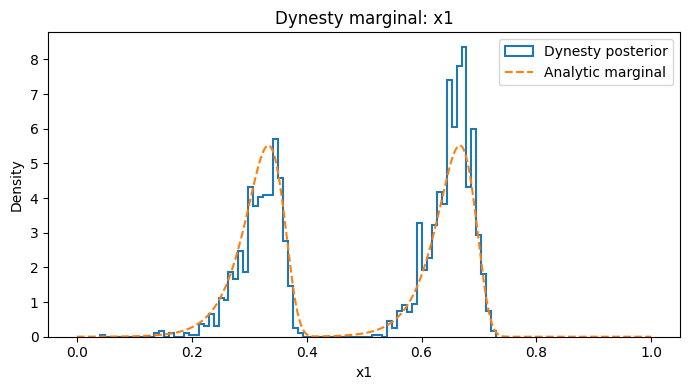

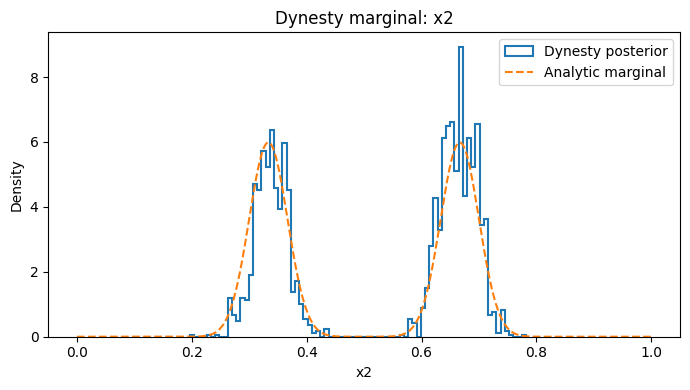

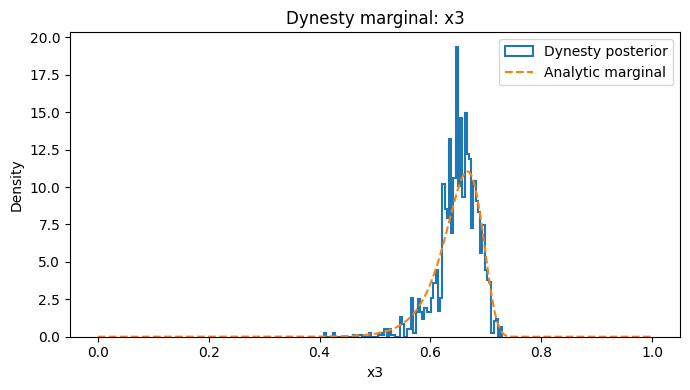

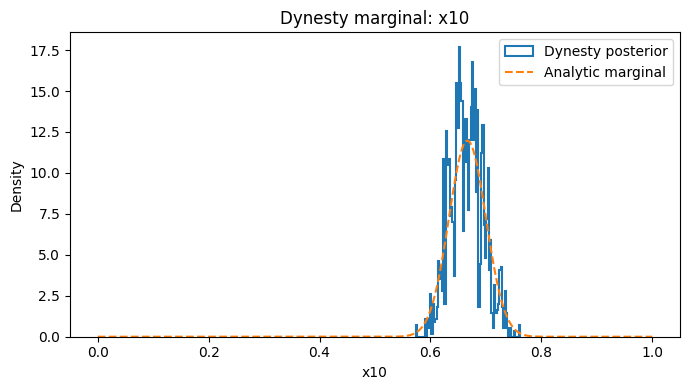

In [47]:
def analytic_marginal_pdf(x: np.ndarray, dimension: int) -> np.ndarray:
    """Analytic normalized posterior marginal before negligible truncation."""
    if dimension == 0:
        return 0.5 * (
            loggamma.pdf(
                x,
                c=LOGGAMMA_SHAPE,
                loc=MODE_LEFT,
                scale=COMPONENT_SCALE,
            )
            + loggamma.pdf(
                x,
                c=LOGGAMMA_SHAPE,
                loc=MODE_RIGHT,
                scale=COMPONENT_SCALE,
            )
        )
    if dimension == 1:
        return 0.5 * (
            norm.pdf(x, loc=MODE_LEFT, scale=COMPONENT_SCALE)
            + norm.pdf(x, loc=MODE_RIGHT, scale=COMPONENT_SCALE)
        )

    split = NDIM // 2 + 1
    if dimension < split:
        return loggamma.pdf(
            x,
            c=LOGGAMMA_SHAPE,
            loc=MODE_RIGHT,
            scale=COMPONENT_SCALE,
        )
    return norm.pdf(x, loc=MODE_RIGHT, scale=COMPONENT_SCALE)


representative_dims = (0, 1, 2, NDIM - 1)
grid = np.linspace(0.0, 1.0, 1_500)

for dim in representative_dims:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        dynesty_posterior[:, dim],
        bins=80,
        density=True,
        histtype="step",
        linewidth=1.5,
        label="Dynesty posterior",
    )
    ax.plot(
        grid,
        analytic_marginal_pdf(grid, dim),
        linestyle="--",
        linewidth=1.5,
        label="Analytic marginal",
    )
    ax.set(
        xlabel=PARAMETER_NAMES[dim],
        ylabel="Density",
        title=f"Dynesty marginal: {PARAMETER_NAMES[dim]}",
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

## 4. Fit the Morph importance distribution to Dynesty posterior samples

In [49]:
morph_rng = np.random.default_rng(SEED + 2)

if len(dynesty_posterior) > MAX_MORPH_TRAINING_SAMPLES:
    training_indices = morph_rng.choice(
        len(dynesty_posterior),
        size=MAX_MORPH_TRAINING_SAMPLES,
        replace=False,
    )
    morph_training_samples = dynesty_posterior[training_indices]
else:
    morph_training_samples = dynesty_posterior.copy()

print("Morph training shape:", morph_training_samples.shape)
print("Morph type:", MORPH_TYPE)

morph_start = time.perf_counter()
importance_morph = MorphProposal.fit(
    morph_training_samples[::3,:],
    param_names=PARAMETER_NAMES,
    morph_type=MORPH_TYPE,
    kde_bw=KDE_BW,
)
morph_seconds = time.perf_counter() - morph_start

print(f"Morph fit completed in {morph_seconds:.2f} s.")

Morph training shape: (2299, 10)
Morph type: 2_group


MI pairs:   0%|          | 0/45 [00:00<?, ?it/s]

Morph fit completed in 1.71 s.


## 5. Run MINS using the fitted Morph and `en-rwalk`

In [54]:
model = CallableModel(
    ndim=NDIM,
    parameter_names=PARAMETER_NAMES,
    log_likelihood_fn=loglikelihood,
    log_prior_fn=logprior,
    vectorized=False,
)

mins_sampler = MINSampler(
    model=model,
    importance_morph=importance_morph,
    proposal_scheme="en-rwalk",
    ensemble_rwalk_settings=EnsembleRWalkSettings(
        n_walkers=8,
        n_sweeps=2,
    ),
    n_live=100,
    rng=SEED + 4,
)

print("Running MINS...")
mins_start = time.perf_counter()
mins_result = mins_sampler.run(
    dlogz=0.01,
    max_iterations=MINS_MAX_ITERATIONS,
    max_proposals_per_replacement=MINS_MAX_PROPOSALS_PER_REPLACEMENT,
    max_likelihood_calls=MINS_MAX_LIKELIHOOD_CALLS,
    progress=True,
)
mins_seconds = time.perf_counter() - mins_start

mins_diagnostics = summarize(mins_result)

n_equal = min(
    20_000,
    max(5_000, len(dynesty_posterior)),
)
mins_posterior = mins_result.resample_equal(
    rng=SEED + 5,
    n_samples=n_equal,
)

print("\n==== MINS RESULTS ====")
print("Success:", mins_result.success)
print("Termination:", mins_result.termination_reason)
print(f"logZ:             {mins_result.logz:.6f} ± {mins_result.logzerr:.6f}")
print(f"Reference logZ:   {TRUE_LOGZ:.6f}")
print(f"Evidence error:   {mins_result.logz - TRUE_LOGZ:+.6f}")
print(f"Iterations:       {mins_result.niter}")
print(f"Likelihood calls: {mins_result.n_likelihood_calls}")
print(f"Wall time:        {mins_seconds:.2f} s")
print("Diagnostics:", mins_diagnostics)

for warning in mins_result.warnings:
    print("WARNING:", warning)

Running MINS...


MINS nlive=100: 0it [00:00, ?it/s]


==== MINS RESULTS ====
Success: True
Termination: remaining_evidence
logZ:             -0.035603 ± 0.098273
Reference logZ:   0.000000
Evidence error:   -0.035603
Iterations:       1050
Likelihood calls: 16900
Wall time:        43.36 s
Diagnostics: RunDiagnostics(posterior_ess=552.1821374864395, relative_posterior_ess=0.48015838042299086, proposal_acceptance_fraction=0.0625, maximum_proposals_per_replacement=16, thresholds_monotone=True, conservative_log_remaining=-4.096771612411857, final_remaining_fraction=0.009907521849957456, final_remaining_dlogz=0.009956927943385865, final_live_ess=97.42284333842677, final_live_mean_rse=0.0163464109219238, final_live_logz_error=0.00016195242337734326, final_logz_stability=9.980548132206002e-05, final_stopping_streak=1)


## 6. Evidence and computational-cost comparison

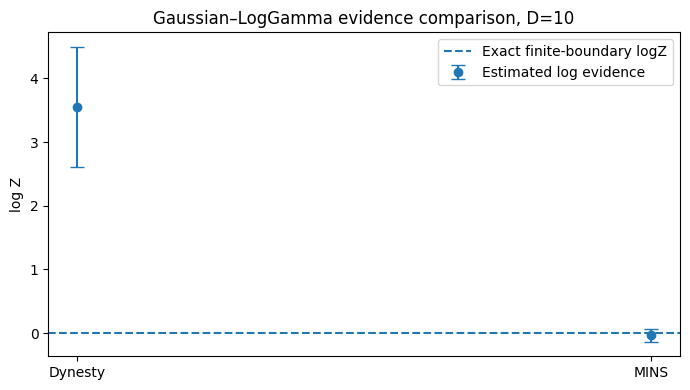

,method,logz,logzerr,error_from_truth,likelihood_calls,wall_seconds,success
0,Dynesty,3.549774,0.943737,3.549774,63960,25.259212,True
1,MINS,-0.035603,0.098273,-0.035603,16900,43.356537,True


In [58]:
comparison = pd.DataFrame(
    [
        {
            "method": "Dynesty",
            "logz": dynesty_logz,
            "logzerr": dynesty_logzerr,
            "error_from_truth": dynesty_logz - TRUE_LOGZ,
            "likelihood_calls": dynesty_ncall,
            "wall_seconds": dynesty_seconds,
            "success": True,
        },
        {
            "method": "MINS",
            "logz": mins_result.logz,
            "logzerr": mins_result.logzerr,
            "error_from_truth": mins_result.logz - TRUE_LOGZ,
            "likelihood_calls": mins_result.n_likelihood_calls,
            "wall_seconds": mins_seconds,
            "success": mins_result.success,
        },
    ]
)
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(comparison))

ax.errorbar(
    x,
    comparison["logz"],
    yerr=comparison["logzerr"],
    fmt="o",
    capsize=5,
    label="Estimated log evidence",
)
ax.axhline(
    TRUE_LOGZ,
    linestyle="--",
    linewidth=1.5,
    label="Exact finite-boundary logZ",
)
ax.set(
    xticks=x,
    xticklabels=comparison["method"],
    ylabel="log Z",
    title=f"Gaussian–LogGamma evidence comparison, D={NDIM}",
)
ax.legend()
fig.tight_layout()
plt.show()

comparison

## 7. Compare posterior marginals

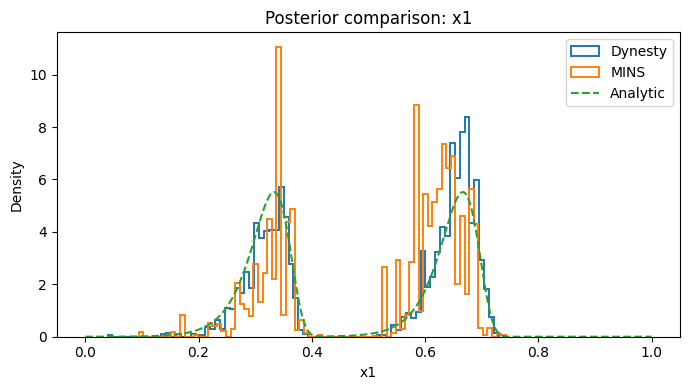

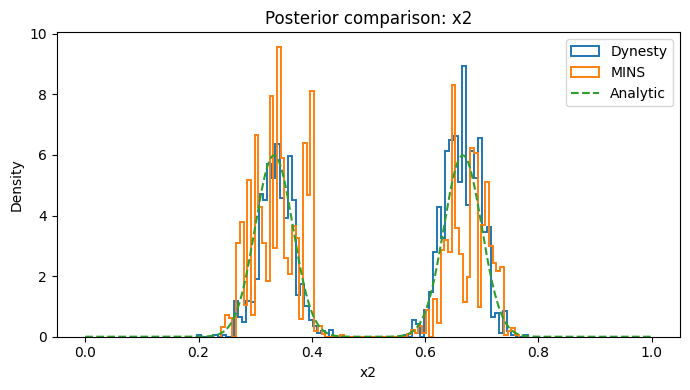

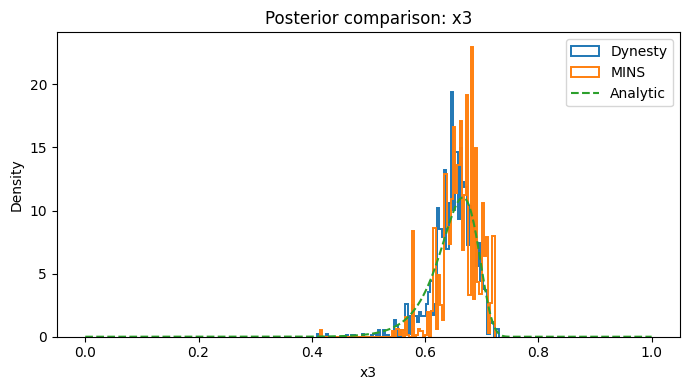

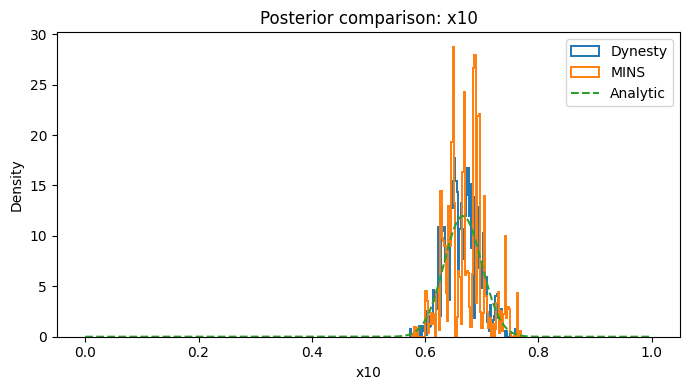

In [59]:
for dim in representative_dims:
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(
        dynesty_posterior[:, dim],
        bins=80,
        density=True,
        histtype="step",
        linewidth=1.4,
        label="Dynesty",
    )
    ax.hist(
        mins_posterior[:, dim],
        bins=80,
        density=True,
        histtype="step",
        linewidth=1.4,
        label="MINS",
    )
    ax.plot(
        grid,
        analytic_marginal_pdf(grid, dim),
        linestyle="--",
        linewidth=1.5,
        label="Analytic",
    )
    ax.set(
        xlabel=PARAMETER_NAMES[dim],
        ylabel="Density",
        title=f"Posterior comparison: {PARAMETER_NAMES[dim]}",
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

### Four-mode occupancy

In [60]:
def mode_occupancy(samples: np.ndarray) -> pd.Series:
    """Approximate occupancy of the four separated modes in x1 and x2."""
    left_x1 = samples[:, 0] < 0.5
    left_x2 = samples[:, 1] < 0.5

    labels = np.select(
        [
            left_x1 & left_x2,
            left_x1 & ~left_x2,
            ~left_x1 & left_x2,
            ~left_x1 & ~left_x2,
        ],
        [
            "(1/3, 1/3)",
            "(1/3, 2/3)",
            "(2/3, 1/3)",
            "(2/3, 2/3)",
        ],
    )
    return (
        pd.Series(labels)
        .value_counts(normalize=True)
        .reindex(
            [
                "(1/3, 1/3)",
                "(1/3, 2/3)",
                "(2/3, 1/3)",
                "(2/3, 2/3)",
            ],
            fill_value=0.0,
        )
    )


occupancy = pd.DataFrame(
    {
        "Expected": np.full(4, 0.25),
        "Dynesty": mode_occupancy(dynesty_posterior),
        "MINS": mode_occupancy(mins_posterior),
    }
)
occupancy

,Expected,Dynesty,MINS
"(1/3, 1/3)",0.25,0.204872,0.3044
"(1/3, 2/3)",0.25,0.204437,0.0500
"(2/3, 1/3)",0.25,0.217486,0.2840
"(2/3, 2/3)",0.25,0.373206,0.3616


### Corner plots for representative dimensions

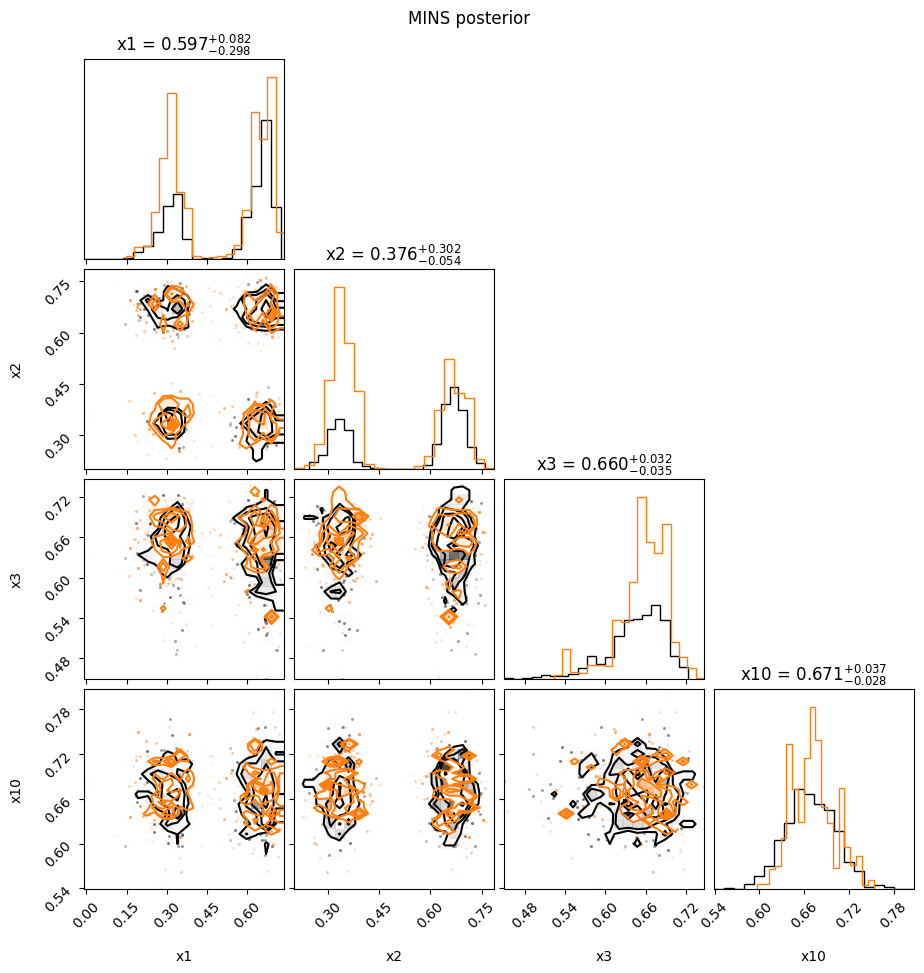

In [43]:
corner_dims = (0, 1, 2, NDIM - 1)
corner_labels = [PARAMETER_NAMES[index] for index in corner_dims]

fig = corner.corner(
    dynesty_posterior[:, corner_dims],
    labels=corner_labels,
    show_titles=True,
    title_fmt=".3f",
)

corner.corner(
    mins_posterior[:, corner_dims],
    color="C1",
    labels=corner_labels,
    show_titles=True,
    title_fmt=".3f",
    fig=fig
)
plt.suptitle("MINS posterior", y=1.01)
plt.show()

## 9. Suggested benchmark extensions

For a robust comparison, repeat the complete notebook over multiple seeds and record:

- $\widehat{\log Z}-\log Z_{\rm true}$;
- reported `logzerr` versus run-to-run scatter;
- likelihood calls and wall time;
- posterior KS or Wasserstein distances;
- occupancy of all four modes;
- MINS proposal acceptance and posterior ESS;
- the result when changing `DYNESTY_SAMPLE` between `"rwalk"` and `"slice"`;
- the result when changing MINS from `"en-rwalk"` to `"rwalk"` or `"s-rwalk"`;
- dimensions $D\in\{10,30,50,100\}$.

A particularly important controlled test is to fit Morph from direct analytic posterior
samples instead of Dynesty output. That separates MINS performance from errors inherited
from the initial Dynesty run.